In [ ]:
# Step 1- Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Step 2 - Set Dataset Path
dataset_path = "/content/drive/MyDrive/dataset"

In [ ]:
# Step 3 - Import Libraries
import tensorflow as tf
import  matplotlib.pyplot as plt

In [ ]:
import os
dataset_path = "/content/drive/MyDrive/dataset"
for root, dirs, files in os.walk(dataset_path):
    print(f"{root}: {len(files)} files")

/content/drive/MyDrive/dataset: 0 files
/content/drive/MyDrive/dataset/One arm crossed: 300 files
/content/drive/MyDrive/dataset/Arms Crossed High (Chest): 305 files
/content/drive/MyDrive/dataset/Arms Crossed Low (Waist): 304 files
/content/drive/MyDrive/dataset/Arms Open and Neutral: 304 files
/content/drive/MyDrive/dataset/Hands in Pockets: 304 files


In [ ]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=(128, 128),
    batch_size=32
)

Found 1517 files belonging to 5 classes.
Using 1214 files for training.


In [ ]:
val_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=(128, 128),
    batch_size=32
)

Found 1517 files belonging to 5 classes.
Using 303 files for validation.


In [ ]:
num_classes = 5

model = models.Sequential([
    tf.keras.layers.Rescaling(1./255),
    layers.Conv2D(32, (3,3), activation='relu',
                  input_shape=(128,128,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Dropout(0.25),

    layers.Flatten(),

    layers.Dense(128, activation='relu'),
    layers.Dropout(0.30),

    layers.Dense(num_classes, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("model")

history = model.fit(
    train_ds,
    epochs=10,
    batch_size=32,
    validation_data=val_ds,
    verbose=1
)

model
Epoch 1/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 119s 3s/step - accuracy: 0.6928 - loss: 3.7878 - val_accuracy: 0.3993 - val_loss: 11.3072
Epoch 2/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 118s 3s/step - accuracy: 0.8781 - loss: 0.7745 - val_accuracy: 0.4950 - val_loss: 8.1634
Epoch 3/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 119s 3s/step - accuracy: 0.9110 - loss: 0.6024 - val_accuracy: 0.8746 - val_loss: 0.7206
Epoch 4/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 148s 3s/step - accuracy: 0.9390 - loss: 0.3247 - val_accuracy: 0.8845 - val_loss: 0.7086
Epoch 5/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 121s 3s/step - accuracy: 0.9563 - loss: 0.2251 - val_accuracy: 0.9274 - val_loss: 0.4853
Epoch 6/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 108s 3s/step - accuracy: 0.9530 - loss: 0.2222 - val_accuracy: 0.8977 - val_loss: 1.1021
Epoch 7/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 113s 3s/step - accuracy: 0.9720 - loss: 0.1632 - val_accuracy: 0.9175 - val_loss: 0.7206
Epoch 8/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 147s 3s/step - accuracy: 0.9827 - loss: 0.0743 - val_accuracy: 0.9

In [ ]:
loss, accuracy = model.evaluate(val_ds)
print(f"Validation Loss: {loss:.4f}")
print(f"Validation Accuracy: {accuracy * 100:.2f}%")
print(f"Training Accuracy: {history.history['accuracy'][-1] * 100:.2f}%")

10/10 ━━━━━━━━━━━━━━━━━━━━ 12s 1s/step - accuracy: 0.9175 - loss: 0.9806
Validation Loss: 0.9806
Validation Accuracy: 91.75%
Training Accuracy: 97.45%


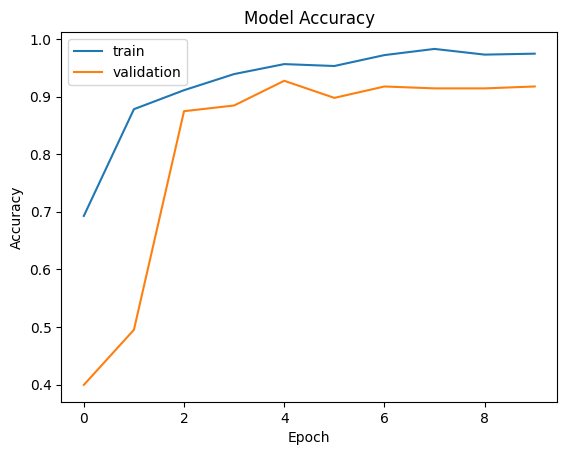

In [ ]:
#Step 11 - Plot Accuracy

plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='validation')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Model Accuracy')
plt.legend()

plt.show()

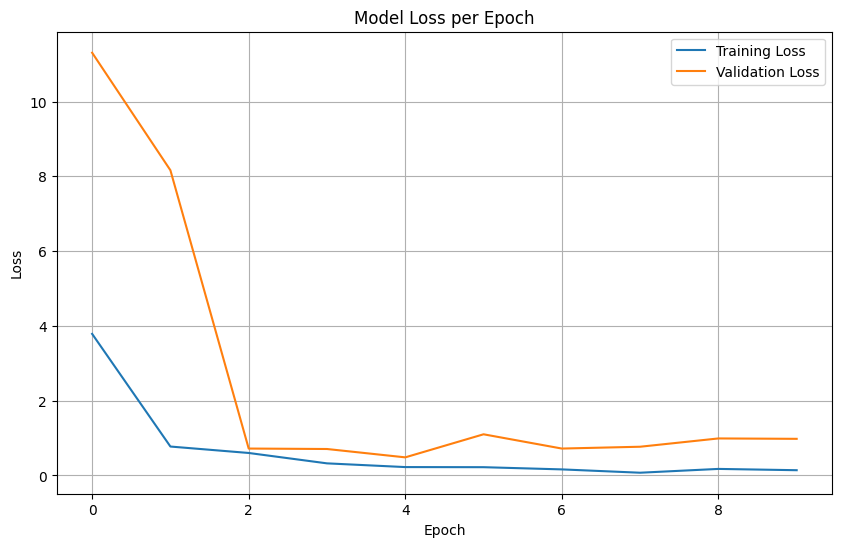

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Model Loss per Epoch')
plt.legend()
plt.grid(True)
plt.show()

Saving 13674299-a-serious-young-woman-is-standing-with-her-hands-in-her-pocket.jpg to 13674299-a-serious-young-woman-is-standing-with-her-hands-in-her-pocket (1).jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
Predicted Class: Hands in Pockets
Confidence Score: 20.01%


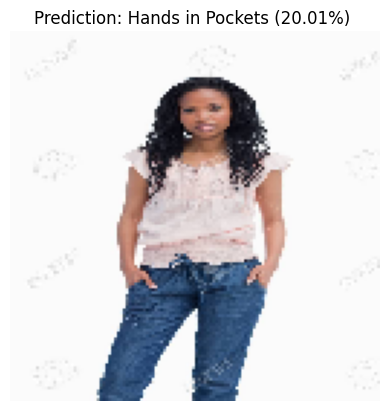

In [ ]:
from google.colab import files
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

# Upload an image file
uploaded = files.upload()

# Get uploaded file name
filename = list(uploaded.keys())[0]

# Load the image and resize to the same size used in training
img = image.load_img(filename, target_size=(128,128))

# Convert image to numpy array
img_array = image.img_to_array(img)

# Normalize pixel values (same preprocessing used during training)
img_array = img_array / 255.0

# Expand dimensions so the model receives a batch
img_array = np.expand_dims(img_array, axis=0)

# Predict class
prediction = model.predict(img_array)

# Get predicted class index and confidence score
predicted_class_index = np.argmax(prediction)
confidence_score = prediction[0][predicted_class_index] * 100

# Retrieve class labels from training dataset
class_labels = train_ds.class_names

# Display the image
plt.imshow(img)
plt.axis('off')

# Display predicted label and confidence score
predicted_class_label = class_labels[predicted_class_index]
print(f"Predicted Class: {predicted_class_label}")
print(f"Confidence Score: {confidence_score:.2f}%")

# Show image with title including predicted class and accuracy score
plt.title(f"Prediction: {predicted_class_label} ({confidence_score:.4}%) ")
plt.show()